# Phase 1: Business Understanding

## Problem
ต้องการวิเคราะห์และจำแนกโซนตลาดตามแนวคิด Wyckoff:
- Normal (ปกติ)
- Accumulation (สะสม)
- Distribution (กระจาย)

## Objective
1) ดึงข้อมูล OHLCV จาก Cassandra
2) สร้างฟีเจอร์ทางเทคนิค 35+ ตัว
3) ทำ Target Labeling แบบ Multi-Strategy Voting
4) ฝึก Deep Learning Hybrid Model (BiLSTM + BiGRU)
5) ประเมินผลด้วย Classification Report และ Confusion Matrix
6) แสดง Dashboard โซน Wyckoff

## Success Criteria
- Accuracy / F1-score สูงขึ้น
- โมเดลสามารถแยกโซนสะสมและกระจายได้ดีขึ้น


Phase 2: Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from cassandra.cluster import Cluster
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import AdamW

warnings.filterwarnings('ignore')

In [3]:
# --- Configuration ---
CASSANDRA_HOST = '127.0.0.1'
CASSANDRA_PORT = 9042
WINDOW_SIZE = 30
SYMBOLS = [
    'CPALL', 'AOT', 'PTT', 'ADVANC', 'BDMS', 'KBANK', 'SCB', 'GULF', 'PTTEP', 'CPN',
    'INTUCH', 'SCC', 'BGRIM', 'CRC', 'OR', 'BANPU', 'TOP', 'IVL', 'KTC', 'MINT'
]


FEATURE_COLS = [
    'returns', 'log_returns', 'volume_ratio_10', 'volume_ratio_30',
    'rsi', 'rsi_slope', 'macd', 'macd_hist', 'stoch_k', 'stoch_d', 
    'mfi', 'obv_slope', 'dist_from_sma_10', 'dist_from_sma_20', 
    'dist_from_sma_50', 'dist_from_ema_10', 'dist_from_ema_20',
    'volatility_5', 'volatility_20', 'atr_10', 'bb_position', 
    'bb_width', 'body_pct', 'upper_shadow_pct', 'lower_shadow_pct',
    'momentum_5', 'momentum_20', 'sma_trend', 'price_above_sma20'
]

Phase 3: Data Preparation (Feature Engineering & Labeling) 
ซึ่งเป็นขั้นตอนที่สำคัญที่สุดก่อนจะนำข้อมูลไปเทรนโมเดล

Phase 3.1: Technical Indicator Functions
ส่วนนี้คือ "เครื่องคำนวณ" พื้นฐานที่ฟังก์ชันหลักต้องเรียกใช้

In [4]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window=period).mean()
    loss = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def calculate_macd(series):
    ema12, ema26 = series.ewm(span=12).mean(), series.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    return macd, signal, macd - signal

Phase 3.2: Feature Engineering (prepare_features)
ส่วนนี้คือการสร้าง "ปัจจัย" หรือ Input ที่โมเดลจะใช้เรียนรู้ (Features)

In [5]:
def prepare_features(df):
    df = df.copy()
    # Returns
    df['returns'] = df['close'].pct_change()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
    
    # Averages & Distances
    for p in [10, 20, 50]:
        df[f'sma_{p}'] = df['close'].rolling(p).mean()
        df[f'dist_from_sma_{p}'] = (df['close'] - df[f'sma_{p}']) / (df[f'sma_{p}'] + 1e-10)
    
    df['ema_10'] = df['close'].ewm(span=10).mean()
    df['ema_20'] = df['close'].ewm(span=20).mean()
    df['dist_from_ema_10'] = (df['close'] - df['ema_10']) / (df['ema_10'] + 1e-10)
    df['dist_from_ema_20'] = (df['close'] - df['ema_20']) / (df['ema_20'] + 1e-10)
    
    # Volatility & Volume
    df['volatility_5'] = df['returns'].rolling(5).std()
    df['volatility_20'] = df['returns'].rolling(20).std()
    df['atr_10'] = ((df['high'] - df['low']) / df['close']).rolling(10).mean()
    df['volume_ratio_10'] = df['volume'] / (df['volume'].rolling(10).mean() + 1)
    df['volume_ratio_30'] = df['volume'] / (df['volume'].rolling(30).mean() + 1)
    
    # Technical Indicators
    df['rsi'] = calculate_rsi(df['close'])
    df['rsi_slope'] = df['rsi'].diff(5)
    df['macd'], _, df['macd_hist'] = calculate_macd(df['close'])
    
    # BBands & Stochastic
    std = df['close'].rolling(20).std()
    df['bb_position'] = (df['close'] - (df['sma_20'] - 2*std)) / (4*std + 1e-10)
    df['bb_width'] = (4*std) / (df['sma_20'] + 1e-10)
    
    low_min, high_max = df['low'].rolling(14).min(), df['high'].rolling(14).max()
    df['stoch_k'] = 100 * (df['close'] - low_min) / (high_max - low_min + 1e-10)
    df['stoch_d'] = df['stoch_k'].rolling(3).mean()
    
    # Momentum & Shadows
    df['mfi'] = calculate_rsi(df['close'] * df['volume'])
    df['obv_slope'] = (np.sign(df['close'].diff()) * df['volume']).fillna(0).cumsum().diff(5)
    
    diff_hl = (df['high'] - df['low'] + 1e-10)
    df['body_pct'] = abs(df['close'] - df['open']) / diff_hl
    df['upper_shadow_pct'] = (df['high'] - df[['close', 'open']].max(axis=1)) / diff_hl
    df['lower_shadow_pct'] = (df[['close', 'open']].min(axis=1) - df['low']) / diff_hl
    
    df['momentum_5'] = df['close'].diff(5)
    df['momentum_20'] = df['close'].diff(20)
    df['sma_trend'] = (df['sma_20'] > df['sma_50']).astype(int)
    df['price_above_sma20'] = (df['close'] > df['sma_20']).astype(int)
    
    # Events for Dashboard
    df['SC'] = ((df['volume'] > df['volume'].rolling(30).mean()*2) & (df['low'] == df['low'].rolling(30).min())).astype(int)
    
    return df.dropna().reset_index(drop=True)

Phase 3.3: Labeling Strategy (create_smart_targets)

In [6]:
# --- Phase 3: โค้ดที่แก้ไขแล้ว ---
def create_smart_targets(df, vote_threshold=3): # ปรับ Threshold ให้สูงขึ้นเพื่อลด Noise
    df = df.copy()
    df['target'] = 0
    
    # ใช้ค่ามัธยฐานของ Volume ในช่วงนั้นๆ เพื่อความแม่นยำ
    vol_h = df['volume'] > df['volume'].rolling(20).median() * 1.5 
    
    # Accumulation: ต้องครบเครื่องจริงๆ
    acc_v = (vol_h).astype(int) + \
            (df['rsi'] < 35).astype(int) + \
            (df['bb_position'] < 0.2).astype(int) + \
            (df['macd_hist'] > 0).astype(int) + \
            (df['close'] > df['ema_10']).astype(int) + \
            (df['lower_shadow_pct'] > 0.4).astype(int) # เพิ่มเงื่อนไขมีไส้เทียนล่าง (แรงซื้อคืน)
            
    # Distribution: ต้องตึงจริงๆ
    dist_v = (vol_h).astype(int) + \
             (df['rsi'] > 65).astype(int) + \
             (df['bb_position'] > 0.8).astype(int) + \
             (df['macd_hist'] < 0).astype(int) + \
             (df['close'] < df['ema_10']).astype(int) + \
             (df['upper_shadow_pct'] > 0.4).astype(int) # เพิ่มเงื่อนไขมีไส้เทียนบน (แรงขายทิ้ง)
             
    df.loc[acc_v >= vote_threshold, 'target'] = 1
    df.loc[dist_v >= vote_threshold, 'target'] = 2
    return df

Phase 4: Data Processing & Feature Scaling
เป็นขั้นตอนรอยต่อที่สำคัญระหว่างการเตรียมข้อมูล (Preparation) และการสร้างโมเดล (Modeling) โดยเน้นไปที่การดึงข้อมูลจาก Database และการทำ Data Transformation ให้พร้อมสำหรับ Neural Network (LSTM)

Phase 4.1: Data Acquisition (ดึงข้อมูลจาก Cassandra)
ส่วนนี้ทำหน้าที่เชื่อมต่อ Database และนำเข้าข้อมูลดิบเพื่อส่งไปผ่านฟังก์ชัน Technical Analysis

In [7]:
def get_multi_stock_data(symbols):
    all_processed = []
    cluster = Cluster([CASSANDRA_HOST], port=CASSANDRA_PORT)
    session = cluster.connect('data_stock')
    for sym in symbols:
        try:
            query = f"SELECT symbol, time, open, high, low, close, volume FROM candlestick_data WHERE symbol = '{sym}' LIMIT 3000 ALLOW FILTERING"
            df = pd.DataFrame(list(session.execute(query)))
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
                df.sort_values('time', inplace=True)
                df_labeled = create_smart_targets(prepare_features(df))
                all_processed.append(df_labeled)
                print(f"✅ Processed: {sym}")
        except Exception as e: print(f"❌ Error {sym}: {e}")
    cluster.shutdown()
    return pd.concat(all_processed, ignore_index=True)


Phase 4.2: Sequence Windowing & Robust Scaling
ส่วนนี้สำคัญมากสำหรับโมเดล LSTM เพราะเราต้องเปลี่ยนข้อมูลจากตาราง (2D) ให้กลายเป็นก้อนลำดับเวลา (3D Sequences) และต้องปรับสเกลข้อมูลให้เป็นมาตรฐานเดียวกัน

In [8]:
def prepare_sequences_multi(df, window_size, feature_cols):
    X, y = [], []
    scaler = RobustScaler()
    scaler.fit(df[feature_cols]) # Fit ข้อมูลทั้งหมดก่อน
    for sym in df['symbol'].unique():
        df_sym = df[df['symbol'] == sym].copy()
        scaled = scaler.transform(df_sym[feature_cols])
        for i in range(window_size, len(scaled)):
            X.append(scaled[i-window_size:i])
            y.append(df_sym['target'].iloc[i])
    return np.array(X), np.array(y), scaler


Phase 4.3: Data Splitting (เตรียมชุดฝึกสอนและทดสอบ)
ขั้นตอนสุดท้ายก่อนเริ่มเทรนโมเดล

In [9]:
# --- Phase 4: Data Processing & Splitting (Modified) ---

# 1. รวบรวมข้อมูลทุก Symbol
df_master = get_multi_stock_data(SYMBOLS)

# 2. แปลงเป็น Sequences และเก็บ Scaler
X_all, y_all, global_scaler = prepare_sequences_multi(df_master, WINDOW_SIZE, FEATURE_COLS)

# --- เพิ่มส่วนตรวจสอบ Class Distribution ---
unique, counts = np.unique(y_all, return_counts=True)
class_counts = dict(zip(unique, counts))
print(f"📊 สถิติจำนวนข้อมูลต่อคลาส: {class_counts}")

# เช็คว่ามีคลาสไหนที่มีสมาชิกน้อยกว่า 2 หรือไม่
if min(counts) < 2:
    print("⚠️ Warning: พบคลาสที่มีข้อมูลน้อยเกินไป ระบบจะปิดการ Stratify เพื่อให้รันต่อได้")
    stratify_target = None
else:
    stratify_target = y_all

# 3. แบ่งข้อมูล (ใช้ตัวแปร stratify_target ที่เราเช็คแล้ว)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, 
    test_size=0.15, 
    random_state=42, 
    stratify=stratify_target 
)

print(f"✅ แบ่งข้อมูลสำเร็จ: Train {len(X_train)} ชุด, Val {len(X_val)} ชุด")

✅ Processed: CPALL
✅ Processed: AOT
✅ Processed: PTT
✅ Processed: ADVANC
✅ Processed: BDMS
✅ Processed: KBANK
✅ Processed: SCB
✅ Processed: PTTEP
✅ Processed: CPN
✅ Processed: SCC
✅ Processed: BGRIM
✅ Processed: CRC
✅ Processed: OR
✅ Processed: BANPU
✅ Processed: TOP
✅ Processed: IVL
✅ Processed: KTC
✅ Processed: MINT
📊 สถิติจำนวนข้อมูลต่อคลาส: {np.int64(0): np.int64(6673), np.int64(1): np.int64(1986), np.int64(2): np.int64(3041)}
✅ แบ่งข้อมูลสำเร็จ: Train 9945 ชุด, Val 1755 ชุด


In [10]:
print("🔍 --- 1. ตรวจสอบ Missing Values และ Data Types ---")
print(df_master[FEATURE_COLS ].info())
print("\nMissing Values per Feature:")
print(df_master[FEATURE_COLS].isnull().sum())


🔍 --- 1. ตรวจสอบ Missing Values และ Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12240 entries, 0 to 12239
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   returns            12240 non-null  float64
 1   log_returns        12240 non-null  float64
 2   volume_ratio_10    12240 non-null  float64
 3   volume_ratio_30    12240 non-null  float64
 4   rsi                12240 non-null  float64
 5   rsi_slope          12240 non-null  float64
 6   macd               12240 non-null  float64
 7   macd_hist          12240 non-null  float64
 8   stoch_k            12240 non-null  float64
 9   stoch_d            12240 non-null  float64
 10  mfi                12240 non-null  float64
 11  obv_slope          12240 non-null  float64
 12  dist_from_sma_10   12240 non-null  float64
 13  dist_from_sma_20   12240 non-null  float64
 14  dist_from_sma_50   12240 non-null  float64
 15  dist_from_ema_10   

In [11]:
print("📊 --- 2. ตรวจสอบสถิติพื้นฐาน (Outliers Check) ---")
# ดูค่า min/max เพื่อเช็คว่ามีค่าโดดผิดปกติ (เช่น RSI > 100 หรือ Volume ติดลบ)
stats = df_master[FEATURE_COLS].describe().T
stats['skew'] = df_master[FEATURE_COLS].skew()
display(stats[['min', '25%', '50%', '75%', 'max', 'skew']])


📊 --- 2. ตรวจสอบสถิติพื้นฐาน (Outliers Check) ---


,min,25%,50%,75%,max,skew
returns,-2.214286e-01,-9.345794e-03,0.000000e+00,8.695685e-03,1.627906e-01,0.046596
log_returns,-2.502945e-01,-9.389740e-03,0.000000e+00,8.658096e-03,1.508228e-01,-0.205767
volume_ratio_10,1.162946e-01,6.649979e-01,9.047182e-01,1.226725e+00,9.067500e+00,2.261581
volume_ratio_30,1.069914e-01,6.241918e-01,8.716104e-01,1.223740e+00,2.174661e+01,5.822331
rsi,0.000000e+00,3.684211e+01,4.833333e+01,6.000000e+01,1.000000e+02,0.044130
rsi_slope,-5.952381e+01,-9.090909e+00,7.692265e-10,9.469289e+00,5.714286e+01,-0.075548
macd,-9.039350e+00,-5.492422e-01,-1.011669e-01,3.526725e-01,9.578819e+00,0.045745
macd_hist,-4.409792e+00,-1.323721e-01,8.202387e-03,1.524012e-01,4.000860e+00,0.047357
stoch_k,0.000000e+00,2.222222e+01,4.827586e+01,7.500000e+01,1.000000e+02,0.045250
stoch_d,0.000000e+00,2.380952e+01,4.791667e+01,7.333333e+01,1.000000e+02,0.054624


In [12]:
print("🗂️ --- 3. ตรวจสอบความครบถ้วนราย Symbol ---")
symbol_counts = df_master.groupby('symbol').size().sort_values(ascending=False)
display(symbol_counts.to_frame(name='Total Records'))

🗂️ --- 3. ตรวจสอบความครบถ้วนราย Symbol ---


,Total Records
symbol,
ADVANC,680
AOT,680
SCC,680
SCB,680
PTTEP,680
PTT,680
OR,680
MINT,680
KTC,680


In [13]:
print(" --- 4. เช็คแท่งเทียนล่าสุด (Example: CPALL) ---")
target_symbol = 'CPALL'
latest_data = df_master[df_master['symbol'] == target_symbol].tail(5)

print(f"Latest 5 records for {target_symbol}:")
display(latest_data[['time', 'open', 'high', 'low', 'close', 'volume'] + FEATURE_COLS[:3]])

 --- 4. เช็คแท่งเทียนล่าสุด (Example: CPALL) ---
Latest 5 records for CPALL:


,time,open,high,low,close,volume,returns,log_returns,volume_ratio_10
675,2026-01-12,42.75,42.75,41.50,41.75,38665658,-0.023392,-0.023670,1.803870
676,2026-01-13,42.00,42.00,40.50,41.00,38029357,-0.017964,-0.018127,1.530545
677,2026-01-14,40.75,41.75,40.50,41.50,18518111,0.012195,0.012121,0.704123
678,2026-01-15,41.50,42.50,41.25,42.25,31551363,0.018072,0.017911,1.178118
679,2026-01-16,42.25,42.50,41.50,42.50,36120781,0.005917,0.005900,1.319304


🕯️ --- 5. แสดงกราฟ Candlestick ล่าสุด (Example: PTT) ---


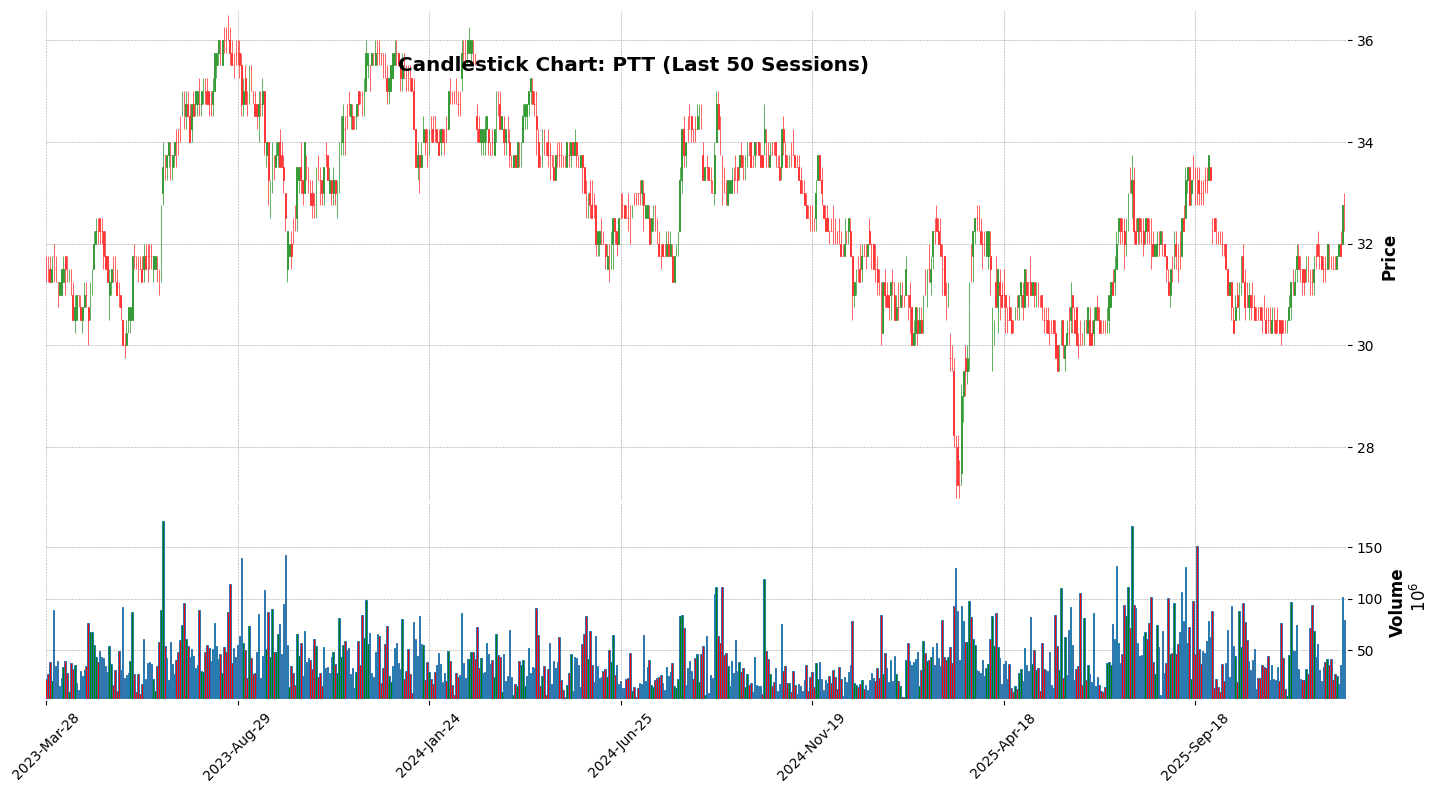

In [14]:
import mplfinance as mpf

print("🕯️ --- 5. แสดงกราฟ Candlestick ล่าสุด (Example: PTT) ---")

# 1. เตรียมข้อมูล PTT และตั้งค่า Index เป็น Datetime (จำเป็นสำหรับ mplfinance)
symbol_to_plot = 'PTT'
df_ptt = df_master[df_master['symbol'] == symbol_to_plot].copy()
df_ptt['time'] = pd.to_datetime(df_ptt['time'])
df_ptt = df_ptt.set_index('time')

# 2. เลือกช่วงข้อมูล (เช่น 50 แท่งล่าสุด) เพื่อให้เห็นแท่งเทียนชัดเจน
plot_df = df_ptt.tail(1000)

# 3. กำหนดสไตล์ของกราฟ (พื้นหลังขาว ตามที่คุณต้องการ)
mc = mpf.make_marketcolors(up='g', down='r', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='charles', marketcolors=mc, gridstyle='--', y_on_right=True)

# 4. วาดกราฟ Candlestick พร้อม Volume
mpf.plot(plot_df, 
         type='candle', 
         style=s,
         title=f'\nCandlestick Chart: {symbol_to_plot} (Last 50 Sessions)',
         ylabel='Price',
         ylabel_lower='Volume',
         volume=True, 
         figsize=(15, 8),
         tight_layout=True)

Phase 5: Model Building & Training

เป็นหัวใจสำคัญของกระบวนการ Deep Learning โดยเป็นการนำข้อมูลที่ผ่านการ Prepare และ Windows-based (3D) มาสร้างสถาปัตยกรรมโครงข่ายประสาทเทียมเพื่อเรียนรู้รูปแบบ (Patterns) ของ Wyckoff

Phase 5.1: Model Architecture (สถาปัตยกรรมโมเดล)

In [15]:
# --- Phase 5: โค้ดที่แก้ไขแล้ว ---
def create_hybrid_model(input_shape):
    inputs = Input(shape=input_shape)
    # เพิ่มความเข้มข้นของ Dropout และ Regularization
    x = Bidirectional(LSTM(24, return_sequences=False))(inputs) # ลด Node ลงเล็กน้อยเพื่อลดการจำ
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x) # เพิ่ม Dropout จาก 0.4 -> 0.5
    
    # เพิ่ม L2 Regularization ให้มากขึ้น
    x = Dense(12, activation='relu', kernel_regularizer=l1_l2(l1=1e-4, l2=5e-3))(x) 
    outputs = Dense(3, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    # ลด Learning Rate ลงเพื่อไม่ให้กระโดดข้ามจุดที่ดีที่สุด
    model.compile(optimizer=AdamW(learning_rate=0.0001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

Phase 5.2: Handling Imbalanced Data (การจัดการความไม่สมดุลของข้อมูล)
ในขั้นตอนนี้เราจะคำนวณ "น้ำหนัก" ให้กับคลาสที่มีข้อมูลน้อย (เช่น Accumulation และ Distribution) เพื่อให้โมเดลไม่เพิกเฉยต่อคลาสเหล่านี้ และไม่ทายแต่คลาส Normal เพียงอย่างเดียวเหมือนที่ปรากฏใน Confusion Matrix ก่อนหน้านี้

In [16]:
model = create_hybrid_model((WINDOW_SIZE, len(FEATURE_COLS)))

# คำนวณ Class Weight เพื่อแก้ปัญหา Data Imbalance
cw = dict(enumerate(compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)))



Phase 5.3: Model Training with Optimization Callbacks (การเทรนโมเดล)
ส่วนนี้คือการรันการเรียนรู้จริง โดยมีการนำ cw จาก Phase 5.2 มาใช้งาน และตั้งค่า Callbacks เพื่อป้องกัน Overfitting (กราฟ Accuracy พุ่งไป 1.0 เร็วเกินไป)

In [17]:
# --- 1.3 Execution ---
history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=100, 
    batch_size=32, 
    class_weight=cw,
    callbacks=[
        # หยุดเทรนหาก val_loss ไม่ดีขึ้นใน 12 รอบ เพื่อป้องกันการจำคำตอบ (Overfit)
        EarlyStopping(patience=12, restore_best_weights=True, monitor='val_loss'),
        # ลดความเร็วในการเรียนรู้ (LR) ลงครึ่งหนึ่งหากเจอจุดที่เรียนรู้ยากขึ้น
        ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_loss')
    ],
    verbose=1
)


Epoch 1/100
311/311 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4642 - loss: 1.6990 - val_accuracy: 0.4268 - val_loss: 1.1610 - learning_rate: 1.0000e-04
Epoch 2/100
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4553 - loss: 1.4428 - val_accuracy: 0.4074 - val_loss: 1.1558 - learning_rate: 1.0000e-04
Epoch 3/100
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4329 - loss: 1.3357 - val_accuracy: 0.3835 - val_loss: 1.1636 - learning_rate: 1.0000e-04
Epoch 4/100
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4086 - loss: 1.2697 - val_accuracy: 0.3652 - val_loss: 1.1706 - learning_rate: 1.0000e-04
Epoch 5/100
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3919 - loss: 1.2331 - val_accuracy: 0.3487 - val_loss: 1.1790 - learning_rate: 1.0000e-04
Epoch 6/100
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3885 - loss: 1.2001 - val_accuracy: 0.3442 - val_loss: 1.1772 - learning_rate: 1.0000e-04
Epoch 7/100
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - ac

Phase 6: Model Evaluation & Performance Analysis
เป็นขั้นตอนการ "สอบไล่" โมเดลหลังจากเทรนเสร็จ เพื่อดูว่ามันเข้าใจพฤติกรรมราคาจริงหรือไม่ หรือแค่ท่องจำข้อมูล (Overfitting)

Phase 6.1: Inference & Statistical Report (การพยากรณ์และรายงานตัวเลข)

In [18]:
# --- 2.1 Model Prediction ---
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- 2.2 Numerical Evaluation (Fixed Version) ---
from sklearn.metrics import classification_report
import numpy as np

print("\n📋 Classification Report:")

# 1. เช็คว่าใน y_val (ค่าจริง) และ y_pred (ค่าที่ทาย) มี Class ID อะไรบ้าง
present_classes = np.unique(np.concatenate([y_val, y_pred]))

# 2. สร้าง List รายชื่อคลาสให้ตรงกับ ID ที่ปรากฏจริง
# Mapping: 0 -> Normal, 1 -> Accumulation, 2 -> Distribution
all_labels = ['Normal', 'Accumulation', 'Distribution']
target_names = [all_labels[i] for i in present_classes]

# 3. รัน Report โดยระบุ labels ให้ชัดเจน
print(classification_report(
    y_val, 
    y_pred, 
    labels=present_classes,
    target_names=target_names
)) 

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.60      0.42      0.49      1001
Accumulation       0.24      0.27      0.26       298
Distribution       0.30      0.47      0.37       456

    accuracy                           0.41      1755
   macro avg       0.38      0.39      0.37      1755
weighted avg       0.46      0.41      0.42      1755



Phase 6.2: Learning Diagnostics (วิเคราะห์การเรียนรู้)
ส่วนนี้ใช้กราฟเพื่อดูพฤติกรรมของโมเดลตลอดช่วงเวลาที่เทรน (Training History)

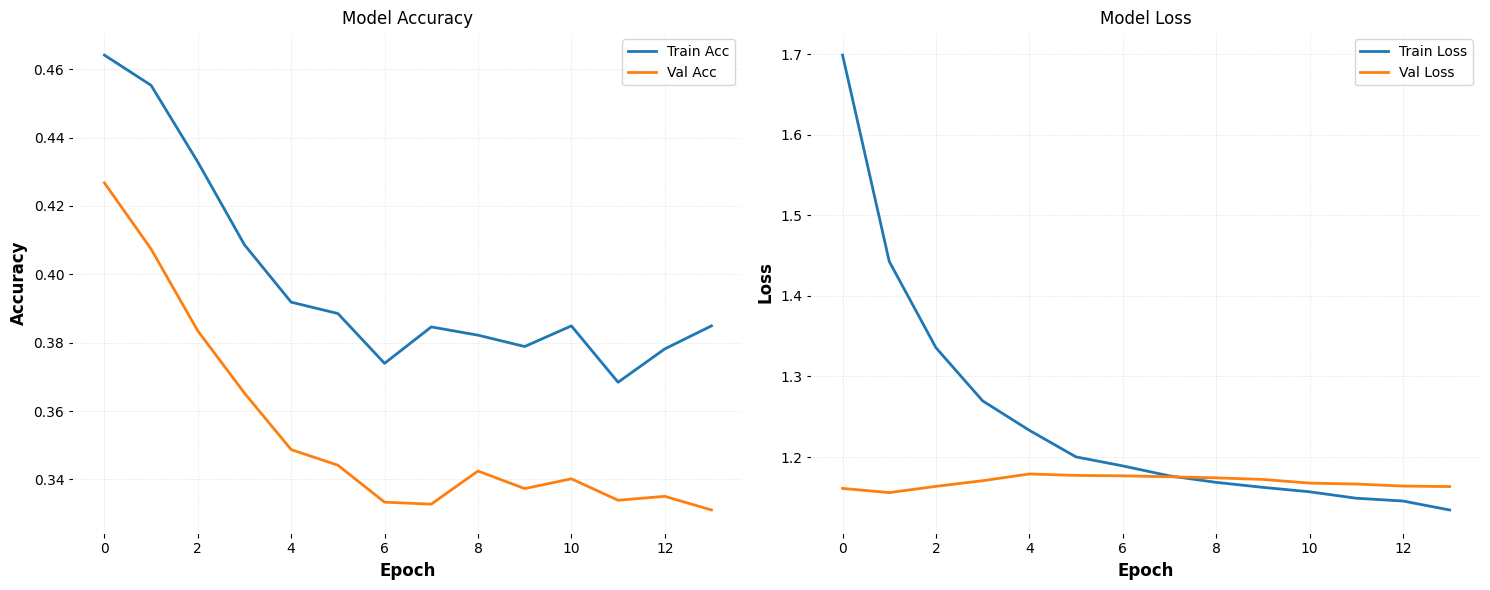

In [19]:
# --- 2.3 Visual Evaluation (Accuracy & Loss History) ---
fig = plt.figure(figsize=(15, 6)) # ปรับขนาดให้พอดีสำหรับ 2 กราฟบน

# กราฟ 1: Accuracy History (โมเดลเรียนรู้ได้แม่นยำขึ้นไหม?)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(history.history['accuracy'], label='Train Acc', color='#1f77b4')
ax1.plot(history.history['val_accuracy'], label='Val Acc', color='#ff7f0e')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# กราฟ 2: Loss History (ความผิดพลาดลดลงอย่างต่อเนื่องไหม?)
ax2 = plt.subplot(1, 2, 2)
ax2.plot(history.history['loss'], label='Train Loss', color='#1f77b4')
ax2.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Phase 6.3: Error Analysis (วิเคราะห์จุดที่ทายผิด)
ใช้ Confusion Matrix เพื่อดูว่าโมเดลแยกแยะคลาสสะสม (Acc) และกระจาย (Dist) ออกจากช่วงเวลาปกติ (Normal) ได้ดีแค่ไหน

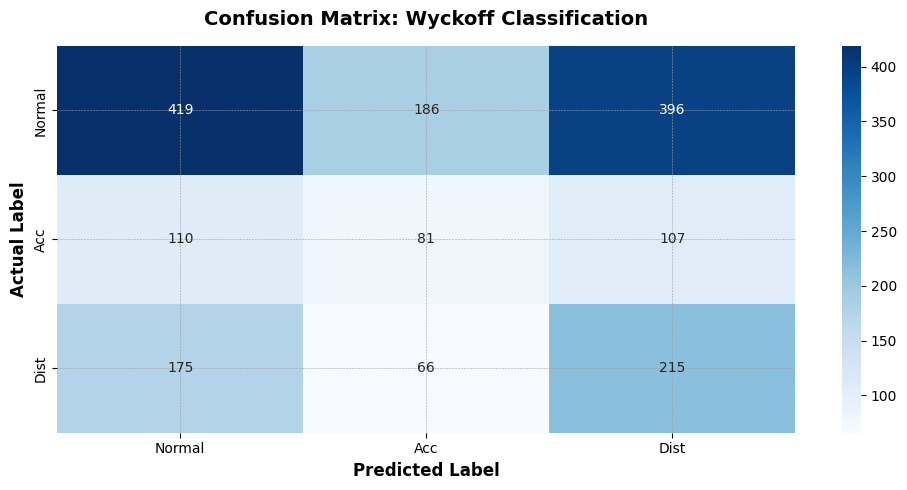

In [20]:
# --- 2.4 Visual Evaluation: Confusion Matrix ---
plt.figure(figsize=(10, 5))
cm = confusion_matrix(y_val, y_pred)

# วาด Heatmap เพื่อให้เห็นภาพการทายผิด/ถูก
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Acc', 'Dist'], 
            yticklabels=['Normal', 'Acc', 'Dist'],
            cbar=True)

plt.title('Confusion Matrix: Wyckoff Classification', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

Phase 7: Live Visualization & Dashboard Implementation
ซึ่งเป็นขั้นตอนสุดท้ายของระบบ โดยทำหน้าที่เป็นส่วนหน้า (Frontend) ที่นำข้อมูล (Data), โมเดลที่เทรนแล้ว (Model), และตัวปรับสเกล (Scaler) มาประมวลผลร่วมกันเพื่อแสดงผลในรูปแบบที่มนุษย์เข้าใจได้ง่าย

Phase 7.1: Real-time Feature Engineering & Rule-based Detection

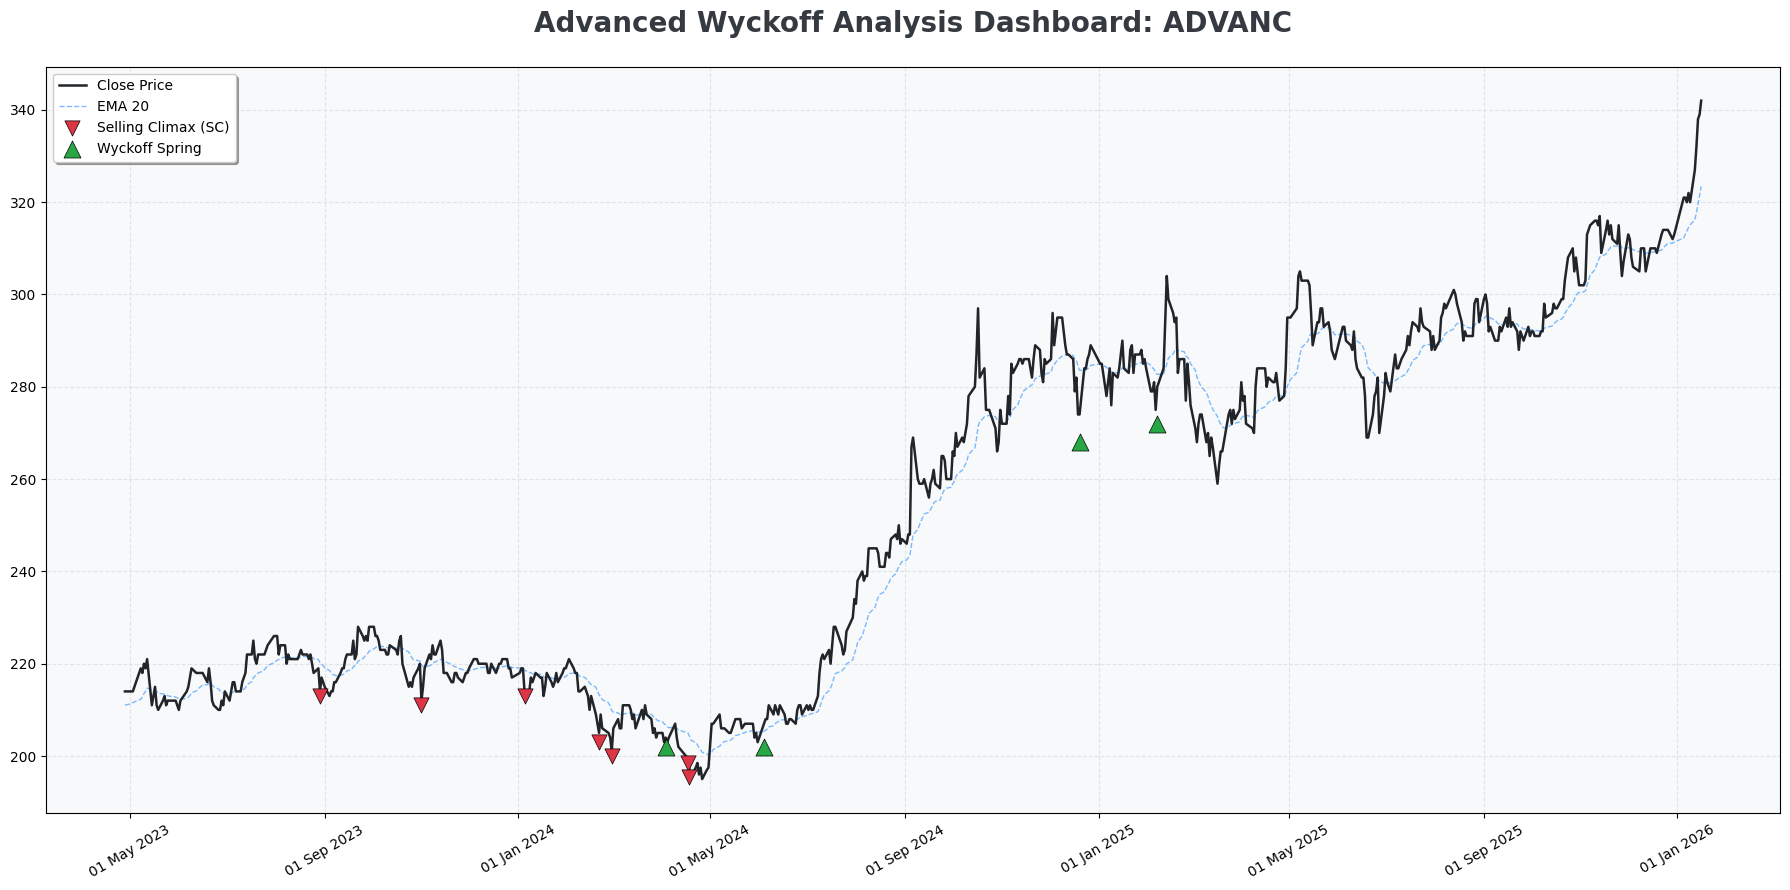

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.dates as mdates
import numpy as np

def plot_dashboard_live(df, model, scaler, symbol="SYMBOL", window_size=30):
    df_plot = df.copy()
    
    # --- 1. เตรียม Feature (ป้องกัน KeyError) ---
    if 'ema_20' not in df_plot.columns:
        df_plot['ema_10'] = df_plot['close'].ewm(span=10).mean()
        df_plot['ema_20'] = df_plot['close'].ewm(span=20).mean()
        df_plot['ema_50'] = df_plot['close'].ewm(span=50).mean()
    
    df_plot['dist_from_ema_10'] = (df_plot['close'] - df_plot['ema_10']) / (df_plot['ema_10'] + 1e-10)
    df_plot['dist_from_ema_20'] = (df_plot['close'] - df_plot['ema_20']) / (df_plot['ema_20'] + 1e-10)
    df_plot['volatility_5'] = df_plot['close'].pct_change().rolling(5).std()
    
    diff_hl = (df_plot['high'] - df_plot['low'] + 1e-10)
    df_plot['upper_shadow_pct'] = (df_plot['high'] - df_plot[['close', 'open']].max(axis=1)) / diff_hl
    df_plot['lower_shadow_pct'] = (df_plot[['close', 'open']].min(axis=1) - df_plot['low']) / diff_hl
    
    std20 = df_plot['close'].rolling(20).std()
    df_plot['bb_width'] = (4 * std20) / (df_plot['close'].rolling(20).mean() + 1e-10)
    df_plot['momentum_5'] = df_plot['close'].diff(5)
    df_plot['momentum_20'] = df_plot['close'].diff(20)
    df_plot['price_above_sma20'] = (df_plot['close'] > df_plot['close'].rolling(20).mean()).astype(int)

# --- 2. เพิ่ม Logic ตรวจจับ SPRING และ SC (จุดที่ทำให้ Spring ไม่ขึ้นก่อนหน้านี้) ---
    # SPRING: ราคาทำ New Low ในรอบ 20 แท่ง แต่ดึงกลับมาปิดเหนือแนวรับเดิมได้ (Reclaim)
    recent_low_20 = df_plot['low'].rolling(window=20).min().shift(1)
    df_plot['SPRING'] = (
        (df_plot['low'] < recent_low_20) & 
        (df_plot['close'] > recent_low_20) & 
        (df_plot['volume'] > df_plot['volume'].rolling(10).mean())
    ).astype(int)

    # SC: ราคาลงแรงทำ New Low พร้อม Volume ที่สูงกว่าค่าเฉลี่ย 1.5 เท่า
    df_plot['SC'] = (
        (df_plot['low'] == df_plot['low'].rolling(30).min()) & 
        (df_plot['volume'] > df_plot['volume'].rolling(30).mean() * 1.5) &
        (df_plot['close'] < df_plot['open'])
    ).astype(int)
    
    feature_cols = [
        'returns', 'log_returns', 'volume_ratio_10', 'volume_ratio_30',
        'rsi', 'rsi_slope', 'macd', 'macd_hist',
        'stoch_k', 'stoch_d', 'mfi', 'obv_slope',
        'dist_from_sma_10', 'dist_from_sma_20', 'dist_from_sma_50',
        'dist_from_ema_10', 'dist_from_ema_20',
        'volatility_5', 'volatility_20', 'atr_10',
        'bb_position', 'bb_width',
        'body_pct', 'upper_shadow_pct', 'lower_shadow_pct',
        'momentum_5', 'momentum_20',
        'sma_trend', 'price_above_sma20'
    ]
    
    df_plot = df_plot.dropna(subset=feature_cols).reset_index(drop=True)
    
    # --- 2. Scaling & Prediction ---
    scaled_data = scaler.transform(df_plot[feature_cols])
    X_live = np.array([scaled_data[i-window_size:i] for i in range(window_size, len(scaled_data))])
    
    probs = model.predict(X_live, verbose=0)
    live_preds = [np.argmax(p) if np.max(p) > 0.80 else 0 for p in probs]
    
    df_plot['dl_zone'] = 0
    df_plot.iloc[window_size:, df_plot.columns.get_loc('dl_zone')] = live_preds
    
    # --- 3. Visualization (White Background) ---
    plt.style.use('default') # ใช้สไตล์มาตรฐาน
    fig, ax = plt.subplots(figsize=(18, 9), facecolor='white')
    ax.set_facecolor('#F8F9FA') # สีพื้นหลังกราฟเทาอ่อนๆ เพื่อให้เส้น Grid ชัดขึ้น
    
    # วาดโซนสี่เหลี่ยม
    zone_types = {
        1: ('#FFD700', 'Accumulation Zone'), 
        2: ('#FF4500', 'Distribution Zone')
    }
    
    for zone_id, (color, label_name) in zone_types.items():
        subset = df_plot[df_plot['dl_zone'] == zone_id].copy()
        if len(subset) > 0:
            temp_df = subset.copy()
            temp_df['diff'] = temp_df.index.to_series().diff().fillna(1)
            group_starts = temp_df[temp_df['diff'] > 1].index.tolist()
            group_starts.insert(0, temp_df.index[0])
            
            for start_idx in group_starts:
                group = temp_df.loc[start_idx:].copy()
                break_pt = group[group['diff'] > 1].index
                end_idx = break_pt[0]-1 if len(break_pt) > 0 else temp_df.index[-1]
                
                box_data = df_plot.loc[start_idx:end_idx]
                if len(box_data) > 2:
                    rect_start = mdates.date2num(box_data['time'].iloc[0])
                    rect_end = mdates.date2num(box_data['time'].iloc[-1])
                    y_min = box_data['low'].min()
                    y_max = box_data['high'].max()
                    
                    rect = patches.Rectangle(
                        (rect_start, y_min), rect_end - rect_start, y_max - y_min,
                        linewidth=1, edgecolor=color, facecolor=color, alpha=0.2,
                        label=label_name, zorder=2
                    )
                    ax.add_patch(rect)

    # วาดเส้นราคาและ EMA
    ax.plot(df_plot['time'], df_plot['close'], color='#212529', linewidth=1.8, label='Close Price', zorder=3)
    ax.plot(df_plot['time'], df_plot['ema_20'], color='#007BFF', linestyle='--', linewidth=1, label='EMA 20', alpha=0.5)
    
    # วาด Markers (SC & SPRING)
    if 'SC' in df_plot.columns:
        sc = df_plot[df_plot['SC'] == 1]
        ax.scatter(sc['time'], sc['low'], color='#DC3545', marker='v', s=120, 
                   label='Selling Climax (SC)', edgecolors='black', linewidth=0.5, zorder=5)
    
    if 'SPRING' in df_plot.columns:
        spring = df_plot[df_plot['SPRING'] == 1]
        ax.scatter(spring['time'], spring['low'], color='#28A745', marker='^', s=150, 
                   label='Wyckoff Spring', edgecolors='black', linewidth=0.5, zorder=5)

    # ปรับแต่งแกนและตาราง
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    plt.xticks(rotation=30, fontsize=10)
    plt.yticks(fontsize=10)
    ax.set_title(f'Advanced Wyckoff Analysis Dashboard: {symbol}', fontsize=20, fontweight='bold', color='#343A40', pad=25)
    ax.grid(True, linestyle='--', alpha=0.9, color='#DEE2E6')
    
    # Legend Filter (แสดงชื่อเดียว)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, shadow=True, facecolor='white')
    
    plt.tight_layout()
    plt.show()

# --- วิธีเรียกใช้งาน ---
SYMBOL_TO_CHECK = 'ADVANC' # ใส่ชื่อหุ้นที่ต้องการ
df_sample = df_master[df_master['symbol'] == SYMBOL_TO_CHECK].copy()
plot_dashboard_live(df_sample, model, global_scaler, symbol=SYMBOL_TO_CHECK)